# Preparación y Análisis Exploratorio de Datos

Este notebook lee automáticamente el archivo `DATA.xlsx`, permite definir labels para las variables, y corre un análisis exploratorio completo:

| Sección | Contenido |
|---------|----------|
| 2 | Leer datos |
| 3 | Estadísticos descriptivos |
| 4 | Series de tiempo |
| 5 | Histogramas + KDE |
| 6 | Boxplots |
| 7 | Matriz de correlación |
| 8 | ACF / PACF |
| 9 | Descomposición estacional + Test ADF |
| 10 | Cointegración (Johansen) |
| 11 | Todo junto (opcional) |

>  **Solo necesitas editar la celda de configuración (sección 1).** El resto corre automáticamente para cualquier número de variables.


## Imports

In [13]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Ruta de funciones ─────────────────────────────────────────────────
RUTA_FUNC = os.path.abspath('funciones')
if RUTA_FUNC not in sys.path:
    sys.path.insert(0, RUTA_FUNC)

# ── Funciones del proyecto ────────────────────────────────────────────
from filtro_datos import (
    leer_data,
    estadisticos,
    plot_series,
    plot_histogramas,
    plot_boxplots,
    plot_correlacion,
    plot_acf_pacf,
    EVENTOS,
)

from funciones_desestacionalizacions import (
    analizar_estacionalidad,
    plot_descomposicion,
)

from funciones_estacionariedad import (
    correr_todos,
    tabla_estilizada,
    plot_variable_con_tests,
    construir_ui,
)

# ── Estilo de gráficos ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'         : 120,
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : '#F8F9FA',
    'axes.edgecolor'     : '#CCCCCC',
    'axes.grid'          : True,
    'grid.color'         : 'white',
    'grid.linewidth'     : 1.0,
    'font.family'        : 'sans-serif',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
})

print(' Librerías y funciones cargadas correctamente')

 Librerías y funciones cargadas correctamente



##  CONFIGURACIÓN  (Edita los labels de variables)
Esta es la **única celda que necesitas modificar** cuando cambies la data del excel DATA

In [8]:
#  Ruta al Excel (relativa al notebook) 
RUTA_DATA = 'data/DATA.xlsx'
# Labels de variables
# Formato: {'nombre_en_excel': 'Label largo para gráficos'}
# Si no quieres renombrar una variable, simplemente borra esa línea.
# Sigue el orden de las columnas en el Excel para evitar confusiones.
LABELS = {
    'expec': 'Expectativas Empresariales (3m)',
    'tasa' : 'Tasa de Referencia BCRP (%)',
    'gpbi' : 'Crecimiento PBI (% interanual)',
    'gipx' : 'Términos de Intercambio (var%)',
}
# Eventos a marcar en gráficos 
# Opciones disponibles: 'COVID', 'GFC'
# Puedes agregar eventos personalizados en funciones "filtro_datos.py → EVENTOS"
EVENTOS_ACTIVOS = ('COVID', 'GFC')

# ── Periodos por año  (12=mensual · 4=trimestral · 52=semanal) ─────── para descomposición y gráficos de estacionalidad
PERIODO = 12

# ── Método de descomposición ──────────────────────────────────────────
# Opciones: 'stl' (recomendado) | 'additive' | 'multiplicative' | 'x13'
METODO = 'stl'

# Rezagos para ACF/PACF 
LAGS = 24
#  Carpeta para guardar gráficos (None = no guardar) 
CARPETA_OUTPUT = 'resultados/graficos/series'

# ── Ruta de salida ────────────────────────────────────────────────────
RUTA_OUTPUT = 'data/DATA_DESTACIONALIZADA.xlsx'



##  Leer datos

In [9]:
df = leer_data(ruta=RUTA_DATA, labels=LABELS)
df.head()

✅ Data cargada: 253 obs × 4 variables
   Rango: 2004-01-01 → 2025-01-01
   Variables: ['Expectativas Empresariales (3m)', 'Tasa de Referencia BCRP (%)', 'Crecimiento PBI (% interanual)', 'Términos de Intercambio (var%)']


,Expectativas Empresariales (3m),Tasa de Referencia BCRP (%),Crecimiento PBI (% interanual),Términos de Intercambio (var%)
Fecha,,,,
2004-01-01,2.5,54.517134,3.674966,2.680876
2004-02-01,2.5,57.232704,4.245959,5.766826
2004-03-01,2.5,56.514658,5.774257,4.646032
2004-04-01,2.5,57.863501,4.247995,-4.490010
2004-05-01,2.5,56.231454,3.950757,-1.406146


In [10]:
# Vista rápida del rango y valores faltantes
print(f"Rango : {df.index.min().date()} → {df.index.max().date()}")
print(f"Forma : {df.shape}")
print("\nValores faltantes por variable:")
print(df.isna().sum())

Rango : 2004-01-01 → 2025-01-01
Forma : (253, 4)

Valores faltantes por variable:
Expectativas Empresariales (3m)    0
Tasa de Referencia BCRP (%)        0
Crecimiento PBI (% interanual)     0
Términos de Intercambio (var%)     0
dtype: int64


##  Estadísticos Descriptivos

In [5]:
stats = estadisticos(df)
stats

,Obs,Media,Std,Mín,P25,Mediana,P75,Máx,Asim.,Curt.,NaN
Expectativas Empresariales (3m),253,3.776,1.733,0.250,2.750,4.000,4.500,7.750,0.086,0.149,0
Tasa de Referencia BCRP (%),253,54.405,11.451,9.137,46.742,54.232,63.000,75.342,-0.507,0.564,0
Crecimiento PBI (% interanual),253,4.474,7.211,-39.278,2.310,4.198,6.707,59.901,1.129,26.551,0
Términos de Intercambio (var%),253,0.350,2.580,-6.797,-1.413,0.454,1.990,8.020,0.007,0.133,0


## 4. Series de Tiempo
Las zonas sombreadas marcan los eventos históricos configurados en `EVENTOS_ACTIVOS`.

💾 Guardado: resultados/graficos/series/01_series.png


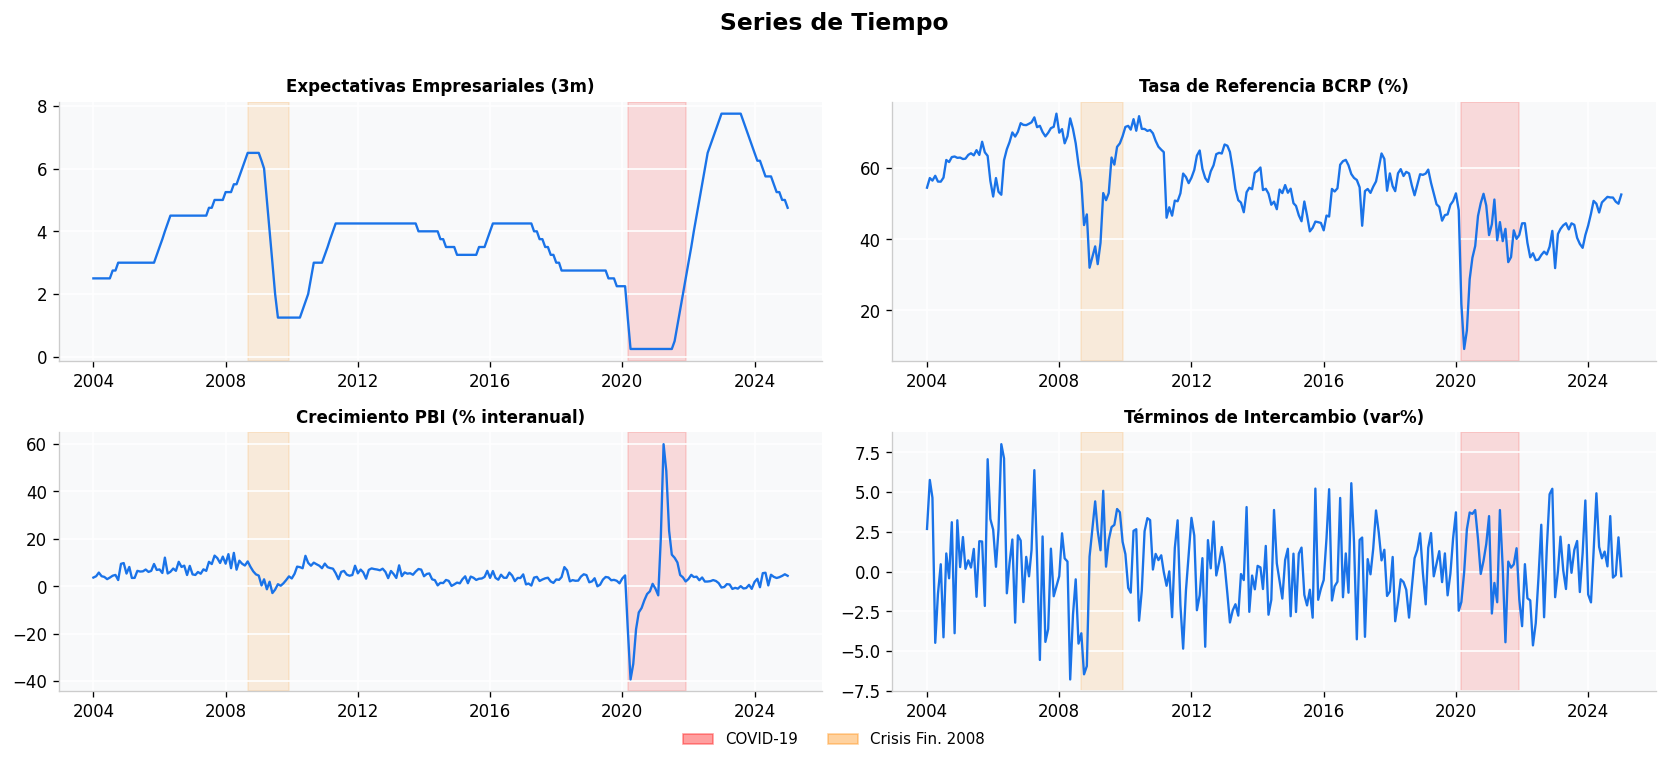

In [6]:
guardar_series = f'{CARPETA_OUTPUT}/01_series.png' if CARPETA_OUTPUT else None
plot_series(
    df,
    eventos_activos=EVENTOS_ACTIVOS,
    guardar=guardar_series,
)

## Histogramas + KDE

💾 Guardado: resultados/graficos/series/02_histogramas.png


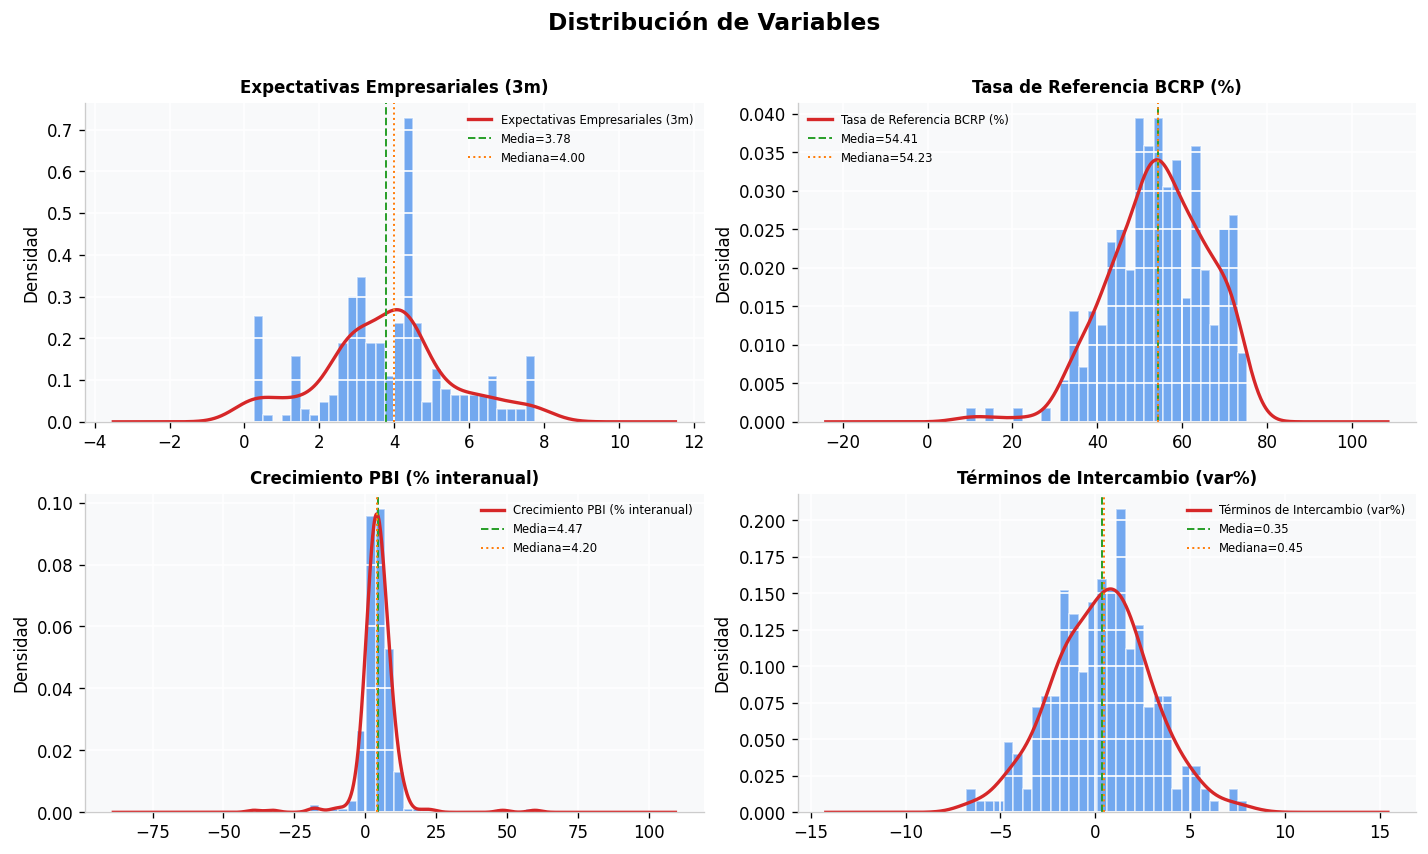

In [7]:
guardar_hist = f'{CARPETA_OUTPUT}/02_histogramas.png' if CARPETA_OUTPUT else None

plot_histogramas(
    df,
    guardar=guardar_hist,
)

## Boxplots

💾 Guardado: resultados/graficos/series/03_boxplots.png


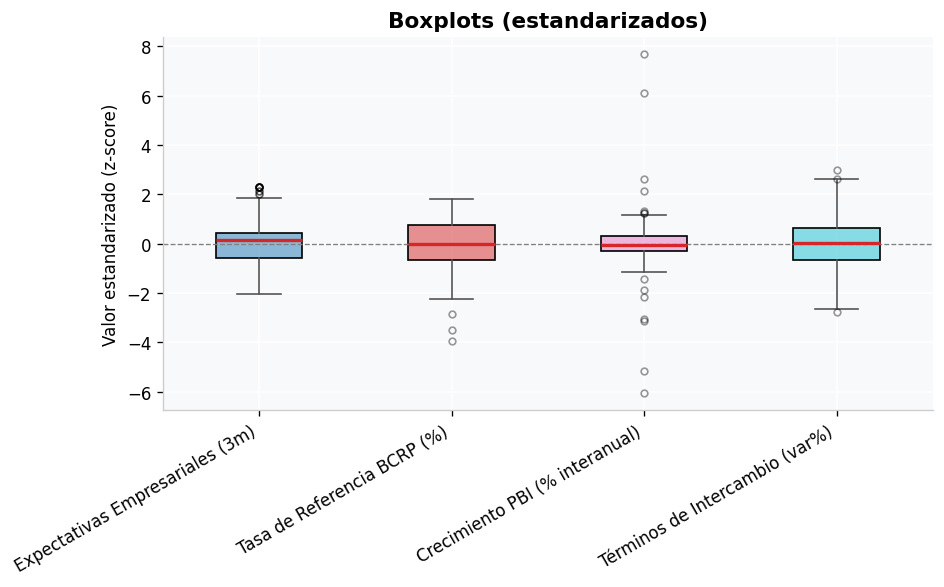

In [8]:
guardar_box = f'{CARPETA_OUTPUT}/03_boxplots.png' if CARPETA_OUTPUT else None

plot_boxplots(
    df,
    guardar=guardar_box,
)

##  Matriz de Correlación

💾 Guardado: resultados/graficos/series/04_correlacion.png


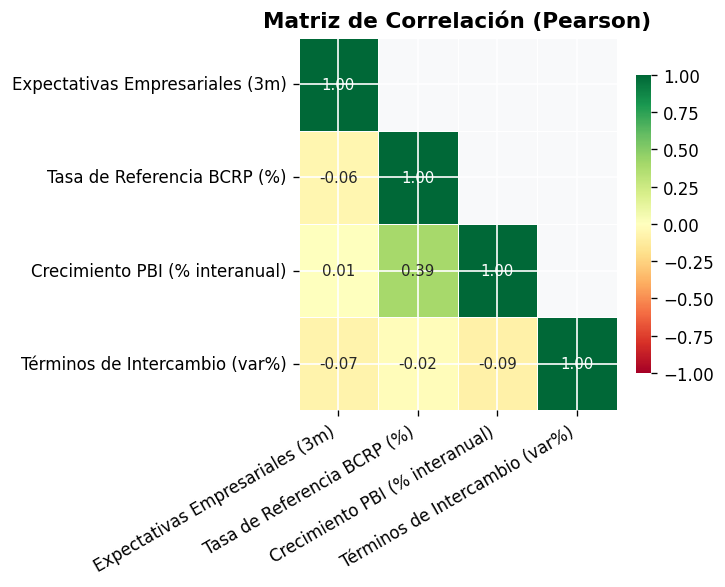

,Expectativas Empresariales (3m),Tasa de Referencia BCRP (%),Crecimiento PBI (% interanual),Términos de Intercambio (var%)
Expectativas Empresariales (3m),1.000000,-0.056680,0.007362,-0.073987
Tasa de Referencia BCRP (%),-0.056680,1.000000,0.393568,-0.021276
Crecimiento PBI (% interanual),0.007362,0.393568,1.000000,-0.090963
Términos de Intercambio (var%),-0.073987,-0.021276,-0.090963,1.000000


In [9]:
guardar_corr = f'{CARPETA_OUTPUT}/04_correlacion.png' if CARPETA_OUTPUT else None

corr = plot_correlacion(
    df,
    guardar=guardar_corr,
)
corr

## ACF / PACF

💾 Guardado: resultados/graficos/series/05_acf_pacf.png


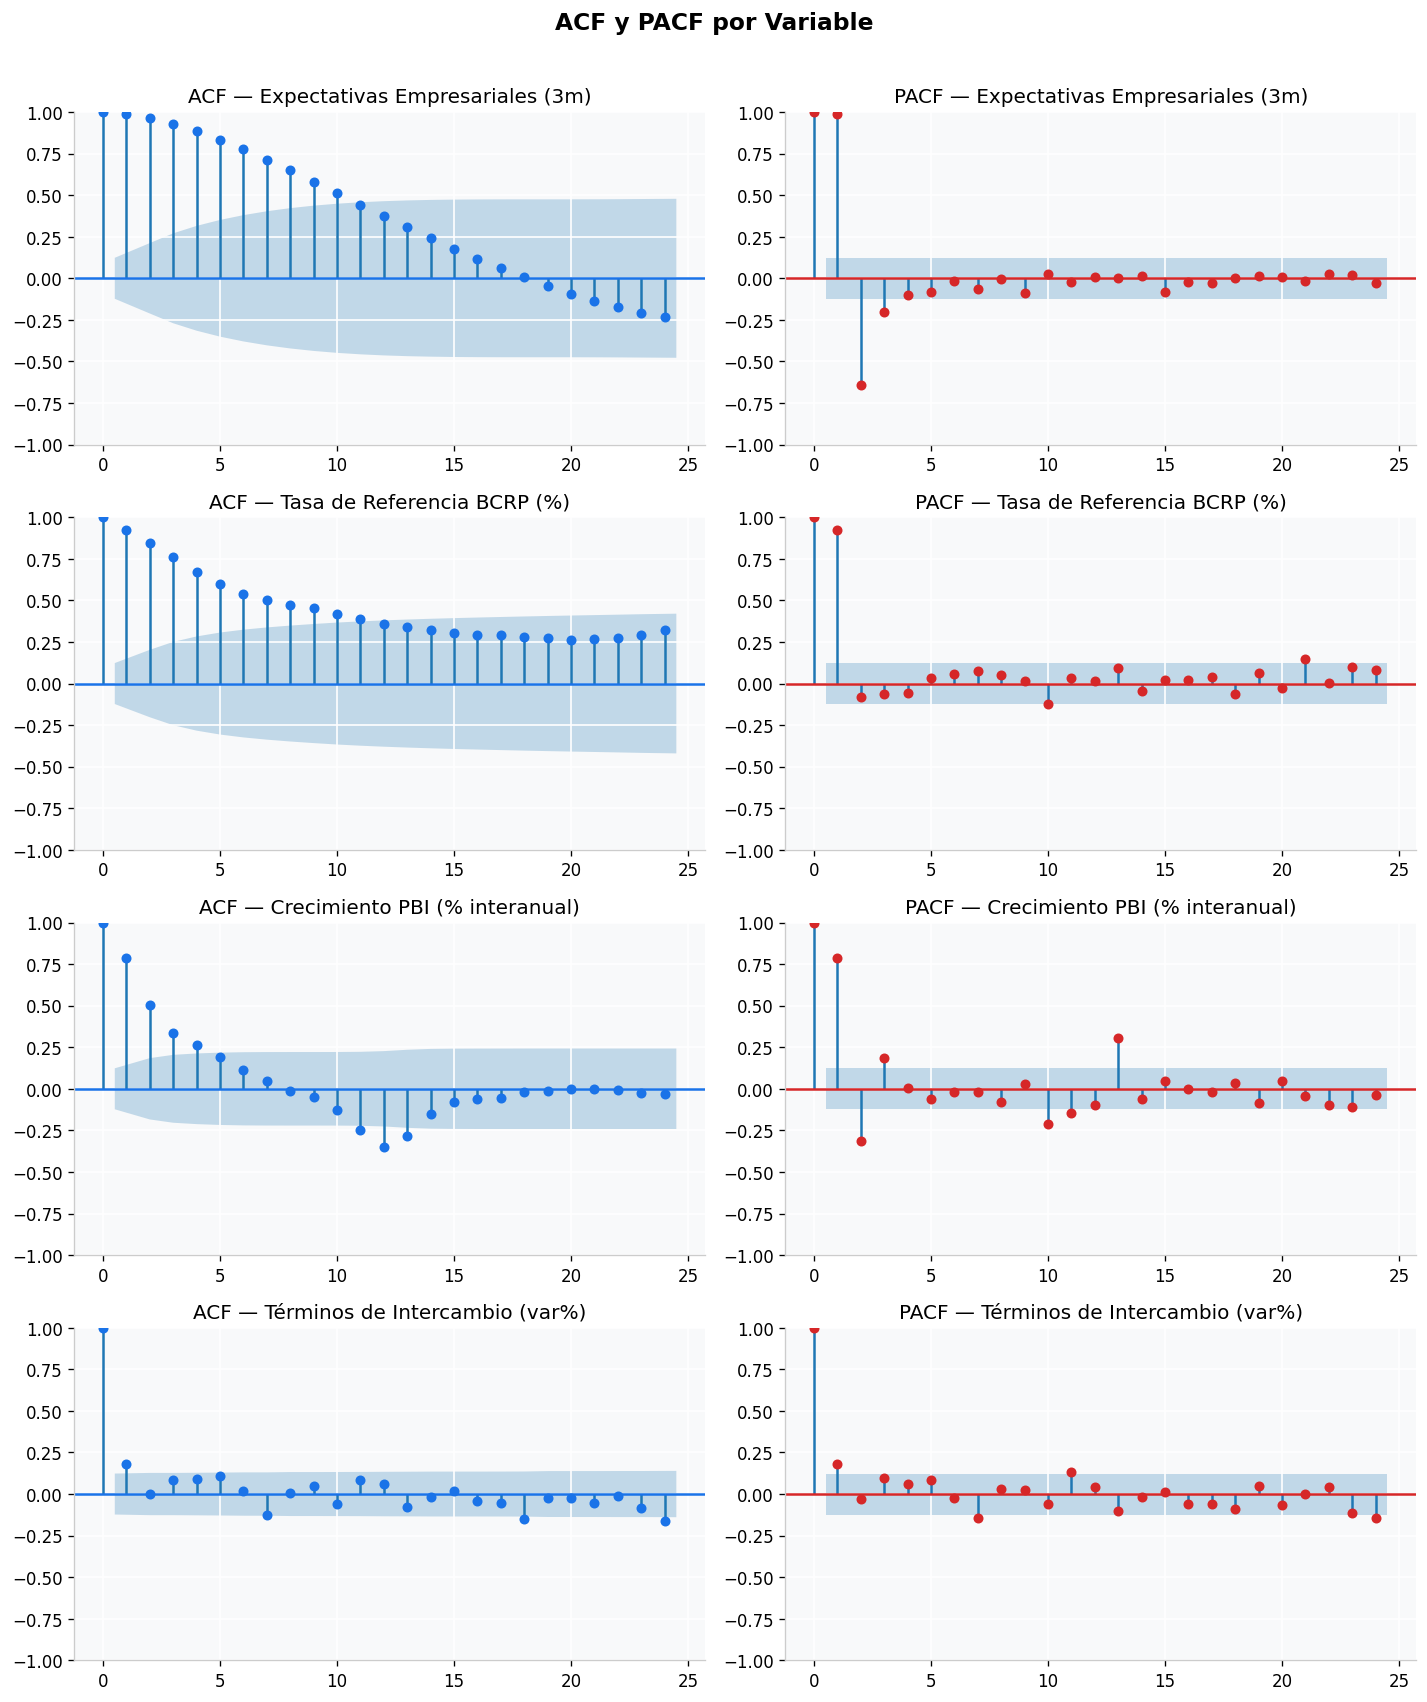

In [10]:
guardar_acf = f'{CARPETA_OUTPUT}/05_acf_pacf.png' if CARPETA_OUTPUT else None

plot_acf_pacf(
    df,
    lags=LAGS,
    guardar=guardar_acf,
)

## Descomposición Estacional 
La descomposición separa cada serie en: **Tendencia**, **Estacionalidad** y **Residuo**.
El test ADF contrasta si cada serie tiene raíz unitaria (H₀) o es estacionaria (Hₐ).

────────────────────────────────────────────────────────────
  Método : STL (Loess) 
  Fórmula: SA = original − estacional
────────────────────────────────────────────────────────────

Generando gráfico de descomposición...
💾 Gráfico guardado: resultados/graficos/series


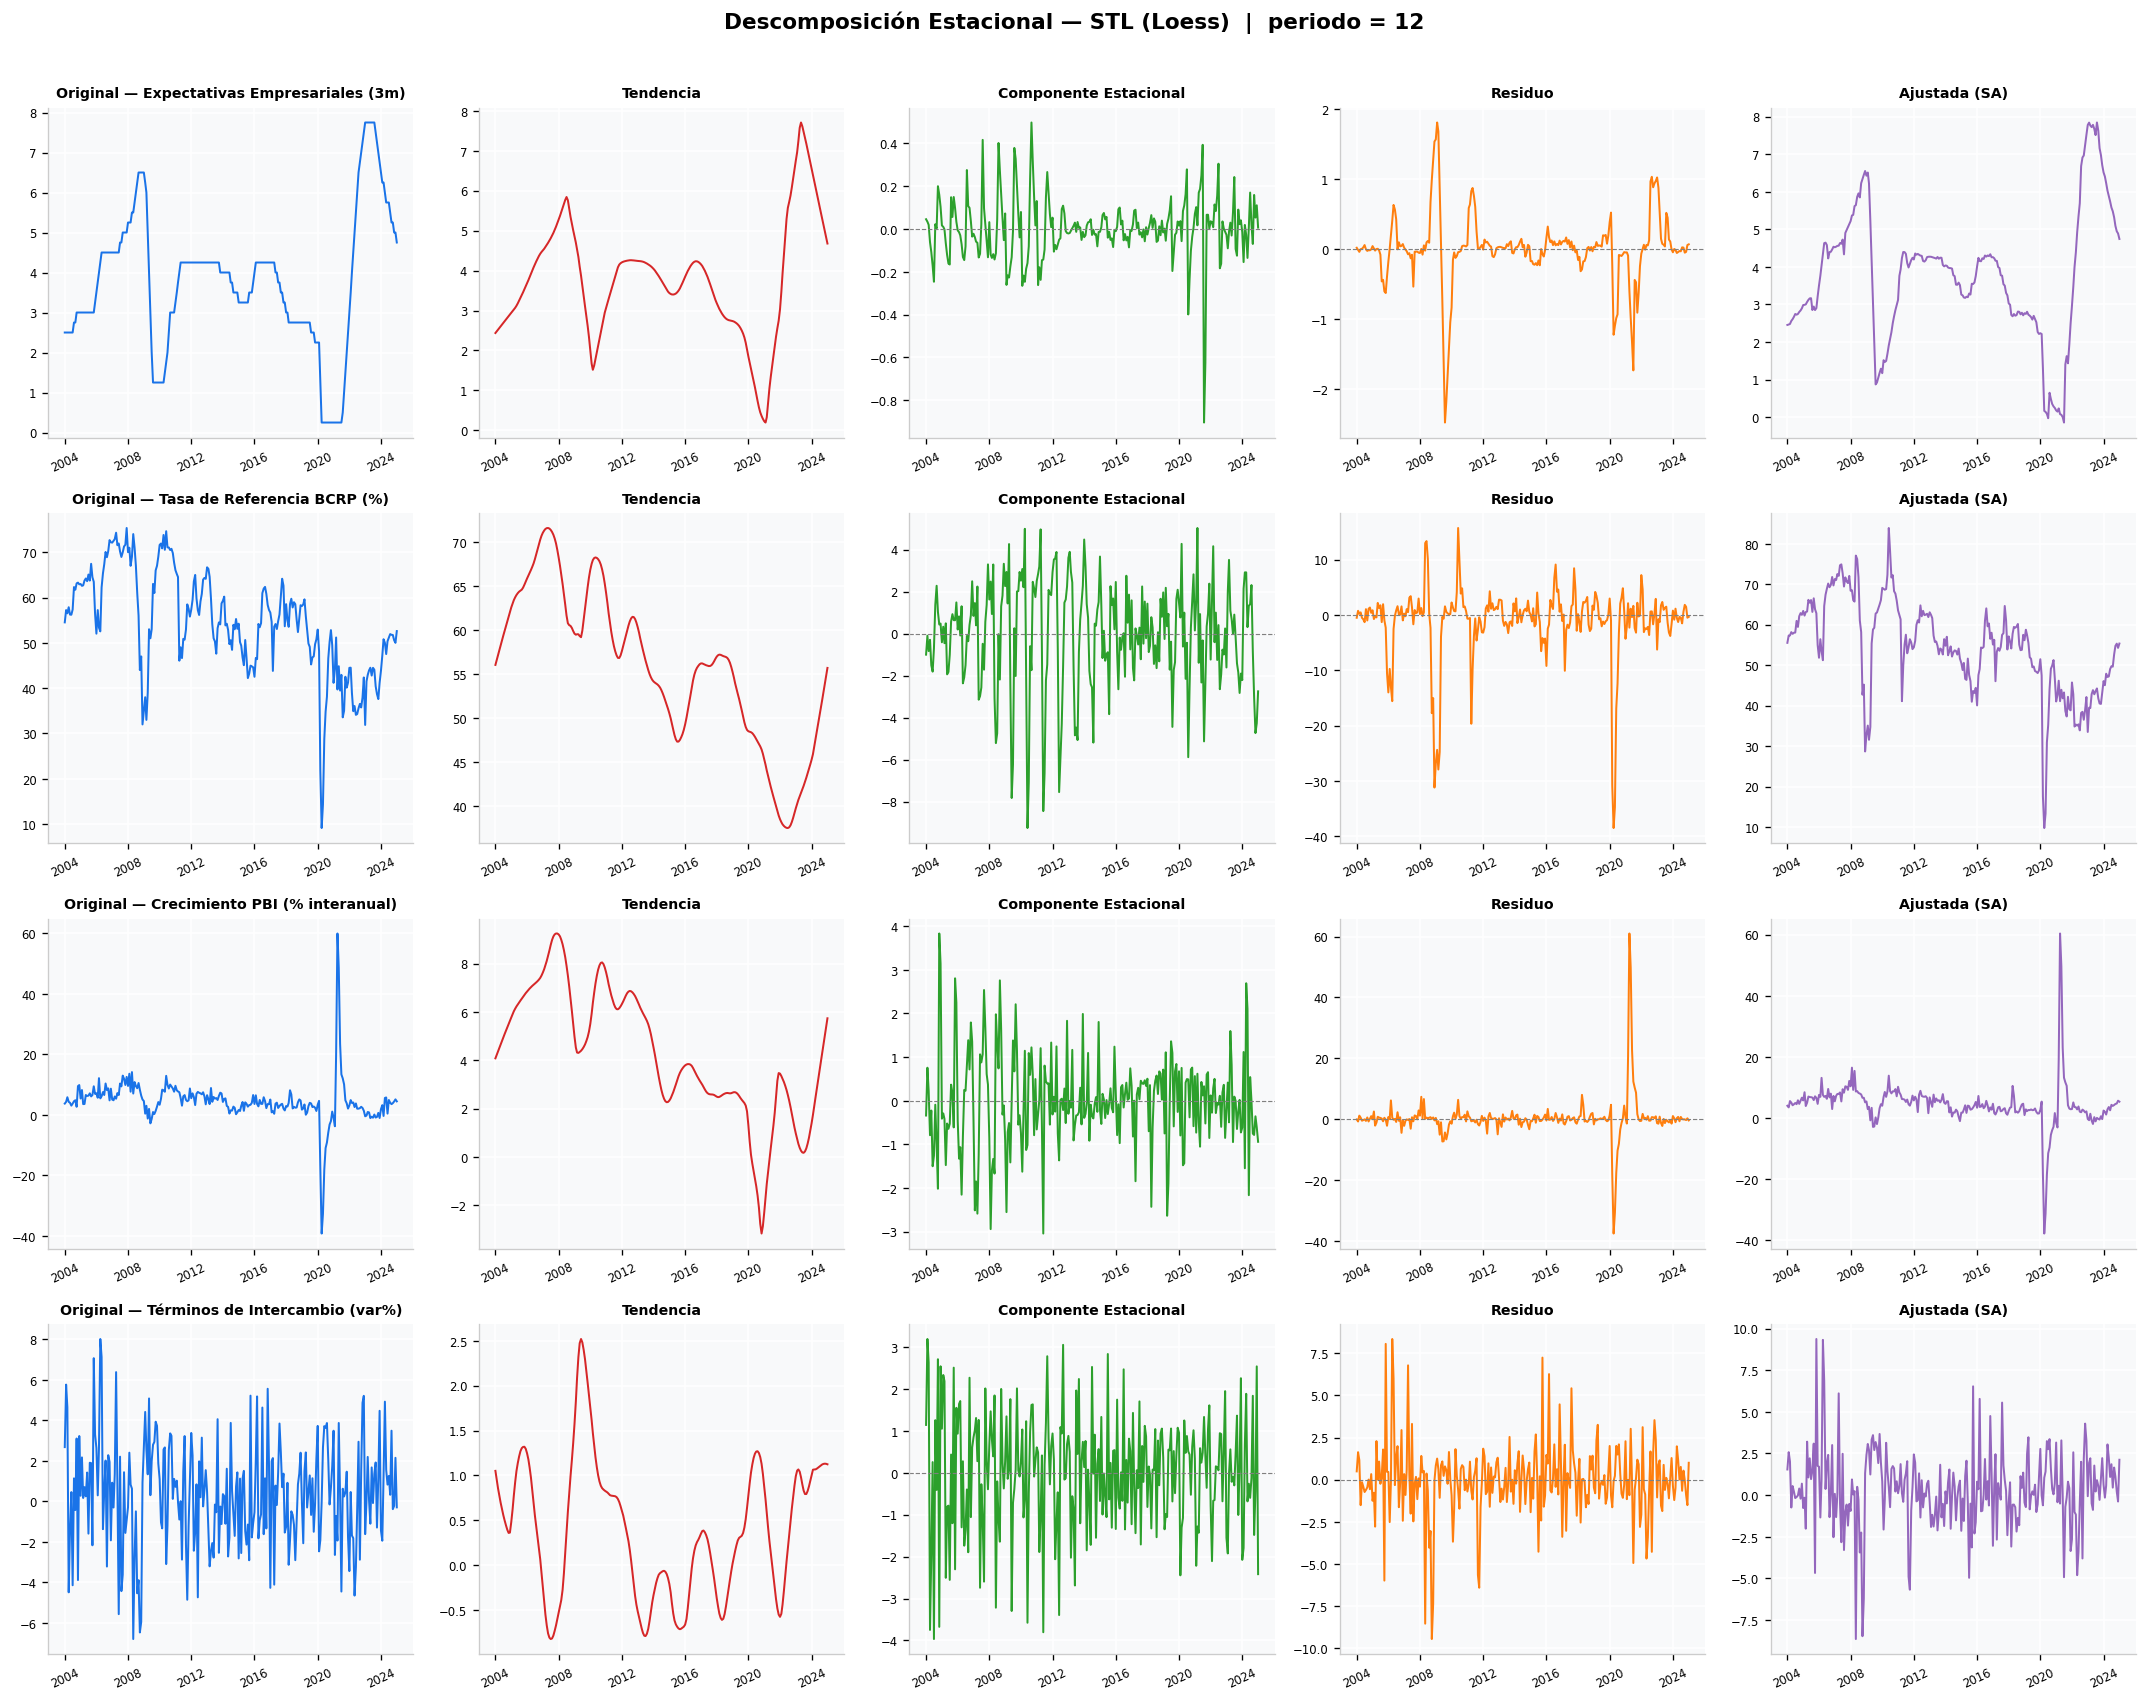


Desestacionalizando series...

DATA_DESTACIONALIZADA guardada: data\DATA_DESTACIONALIZADA.xlsx
   Shape : (253, 4)
   Rango : 2004-01-01 → 2025-01-01


In [14]:

df_sa = analizar_estacionalidad(
    df,
    periodo=PERIODO,
    metodo=METODO,
    ruta_output=RUTA_OUTPUT,
    guardar_grafico=CARPETA_OUTPUT,
)